# g-and-k Plotting Notebook

This notebook is the notebook version of the g-and-k plotting utilities, adapted to this repo layout. It reads saved g-and-k `.npz` files from the project root, renders figures inline, and saves the main summary figure to `figures/gk_summary.pdf`.

In [52]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ROOT = Path.cwd()
RESULTS_DIR = ROOT / "results"/"gnk"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
OUTPUT_FIGURE = FIGURES_DIR / "gk_summary.pdf"

BASE_FIGSIZE = (6, 4)
SUMMARY_FIGSIZE = (24, 4.8)
SUMMARY_DPI = 150
TITLE_SIZE = 32
LABEL_SIZE = 32
TICK_SIZE = 25
LEGEND_SIZE = 32
MARKER_SIZE = 5
LINE_WIDTH = 2.0
COLORS = {
    "sgd": "#1b9e77",
    "sgd_dark": "#0f6f54",
    "natural": "#7570b3",
    "natural_dark": "#5b5696",
    "pgd": "#d95f02",
    "pgd_dark": "#D62728",
    "lhs": "#D62728",
    "rhs": "#111111",
    "truth": "#f4b400",
}

BASE_PLOT_RC = {
    "axes.grid": True,
    "font.family": "DeJavu Serif",
    "font.serif": ["Times New Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amsfonts, mathrsfs, amssymb}",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.frameon": False,
    "legend.fontsize": LEGEND_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": LINE_WIDTH,
    "lines.markersize": MARKER_SIZE,
    "figure.figsize": BASE_FIGSIZE,
    "figure.dpi": 100,
}
LOCAL_PLOT_RC = dict(BASE_PLOT_RC)
plt.rcParams.update(BASE_PLOT_RC)
ROOT, RESULTS_DIR, OUTPUT_FIGURE

(PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL'),
 PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/gnk'),
 PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_summary.pdf'))

In [53]:
def _load_npz_dict(npz_path):
    npz_path = Path(npz_path)
    with np.load(npz_path) as data:
        return {key: data[key] for key in data.files}


def _gk_mmd_and_band_from_f_history(data, prefix, se_scale=1.96):
    mean_key = f"{prefix}_eval_history_mean"
    histories_key = f"{prefix}_eval_histories"
    se_key = f"{prefix}_eval_history_se"

    if histories_key in data:
        f_histories = np.asarray(data[histories_key], dtype=float)
        f_mean = np.nanmean(f_histories, axis=0)
        mmd = np.sqrt(np.maximum(f_mean, 0.0))
        mmd_histories = np.sqrt(np.maximum(f_histories, 0.0))
        valid_counts = np.maximum(np.sum(~np.isnan(mmd_histories), axis=0), 1)
        se = se_scale * np.nanstd(mmd_histories, axis=0) / np.sqrt(valid_counts)
        return mmd, (np.maximum(mmd - se, 0.0), mmd + se)

    f_mean = np.asarray(data[mean_key], dtype=float)
    mmd = np.sqrt(np.maximum(f_mean, 0.0))
    if se_key not in data:
        return mmd, None

    f_se = se_scale * np.asarray(data[se_key], dtype=float)
    lower = np.sqrt(np.maximum(f_mean - f_se, 0.0))
    upper = np.sqrt(np.maximum(f_mean + f_se, 0.0))
    return mmd, (lower, upper)


def _draw_gk_mmd_vs_iteration_plot(ax, data, show_legend=False, show_ylabel=True, se_scale=1.96):
    baseline_steps = np.asarray(data["baseline_history_steps"], dtype=float) + 1.0
    adaptive_steps = np.asarray(data["adaptive_history_steps"], dtype=float) + 1.0
    baseline_mmd, baseline_band = _gk_mmd_and_band_from_f_history(data, "baseline", se_scale=se_scale)
    adaptive_mmd, adaptive_band = _gk_mmd_and_band_from_f_history(data, "adaptive", se_scale=se_scale)

    if baseline_band is not None:
        ax.fill_between(
            baseline_steps,
            baseline_band[0],
            baseline_band[1],
            color=COLORS["sgd"],
            alpha=0.22,
            linewidth=0,
            zorder=1,
        )
    ax.plot(baseline_steps, baseline_mmd, color=COLORS["sgd"], label="GD", zorder=3)
    if "natural_history_steps" in data and "natural_eval_history_mean" in data:
        natural_steps = np.asarray(data["natural_history_steps"], dtype=float) + 1.0
        natural_mmd, natural_band = _gk_mmd_and_band_from_f_history(data, "natural", se_scale=se_scale)
        if natural_band is not None:
            ax.fill_between(
                natural_steps,
                natural_band[0],
                natural_band[1],
                color=COLORS["natural"],
                alpha=0.22,
                linewidth=0,
                zorder=1,
            )
        ax.plot(natural_steps, natural_mmd, color=COLORS["natural"], label="Natural SGD", zorder=3)
    if adaptive_band is not None:
        ax.fill_between(
            adaptive_steps,
            adaptive_band[0],
            adaptive_band[1],
            color=COLORS["pgd"],
            alpha=0.22,
            linewidth=0,
            zorder=1,
        )
    ax.plot(adaptive_steps, adaptive_mmd, color=COLORS["pgd"], label="PGD (ours)", zorder=3)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    if show_ylabel:
        ax.set_ylabel(r"$\mathrm{MMD}_{\ell_\infty}(\mathbb{P}_\theta, \mathbb{Q})$")
    ax.grid(True, which="major", alpha=0.18, linewidth=0.8)
    if show_legend:
        ax.legend()


def _get_lhs_rhs_series(data):
    if all(key in data for key in ("last_adapt_checkpoint_steps", "last_adapt_lhs", "last_adapt_rhs")):
        steps = np.asarray(data["last_adapt_checkpoint_steps"], dtype=float) + 1.0
        lhs = np.asarray(data["last_adapt_lhs"], dtype=float)
        rhs = np.asarray(data["last_adapt_rhs"], dtype=float)
        return steps, lhs, rhs

    if all(key in data for key in ("adaptive_history_steps", "adaptive_lhs_history_mean", "adaptive_rhs_history_mean")):
        steps = np.asarray(data["adaptive_history_steps"], dtype=float) + 1.0
        lhs = np.asarray(data["adaptive_lhs_history_mean"], dtype=float)
        rhs = np.asarray(data["adaptive_rhs_history_mean"], dtype=float)
        return steps, lhs, rhs

    raise KeyError("Could not find adaptive LHS/RHS series in the provided result file.")


def _draw_lhs_rhs_plot(ax, steps, lhs, rhs, show_legend=True, show_ylabel=True):
    steps = np.asarray(steps, dtype=float)
    lhs = np.asarray(lhs, dtype=float)
    rhs = np.asarray(rhs, dtype=float)
    ax.plot(steps, lhs, color=COLORS["lhs"], label="LHS")
    ax.plot(steps, rhs, color=COLORS["rhs"], label="RHS")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    ax.grid(True, which="major", alpha=0.18, linewidth=0.8)
    if show_legend:
        ax.legend()


def _plot_theta_branch(ax, hist, cols, color, markevery):
    ax.plot(hist[:, cols[0]], hist[:, cols[1]], color=color, marker="o", markevery=markevery)
    ax.scatter(hist[0, cols[0]], hist[0, cols[1]], color="white", edgecolors=color, linewidths=1.5, s=50, zorder=4)
    ax.scatter(hist[-1, cols[0]], hist[-1, cols[1]], color=color, marker="s", s=50, zorder=5)


def _draw_gk_mean_theta_trajectories(ax_ab, ax_ck, npz_paths, show_true=True):
    method_colors = {
        "baseline": [COLORS["sgd"], COLORS["sgd_dark"]],
        "natural": [COLORS["natural"], COLORS["natural_dark"]],
        "adaptive": [COLORS["pgd"], COLORS["pgd_dark"]],
    }
    method_keys = {
        "baseline": "baseline_theta_history_mean",
        "natural": "natural_theta_history_mean",
        "adaptive": "adaptive_theta_history_mean",
    }
    theta_true = None

    for idx, npz_path in enumerate(npz_paths):
        data = _load_npz_dict(npz_path)
        theta_true = np.asarray(data["theta_true"], dtype=float)

        for method_name, history_key in method_keys.items():
            if history_key not in data:
                continue

            hist = np.asarray(data[history_key], dtype=float)
            color = method_colors[method_name][idx % len(method_colors[method_name])]
            markevery = max(1, len(hist) // 22)
            _plot_theta_branch(ax_ab, hist, (0, 1), color, markevery)
            _plot_theta_branch(ax_ck, hist, (2, 3), color, markevery)

    if show_true and theta_true is not None:
        ax_ab.scatter(theta_true[0], theta_true[1], marker="*", s=600, color=COLORS["truth"], zorder=6)
        ax_ck.scatter(theta_true[2], theta_true[3], marker="*", s=600, color=COLORS["truth"], zorder=6)

    ax_ab.set_xlabel("Parameter 1")
    ax_ab.set_ylabel("Parameter 2")
    ax_ck.set_xlabel("Parameter 3")
    ax_ck.set_ylabel("Parameter 4")
    ax_ab.grid(True, alpha=0.35)
    ax_ck.grid(True, alpha=0.35)


def make_gk_summary_figure(
    mmd_npz_path,
    trajectory_npz_paths,
    lhs_rhs_npz_path,
    show_method_legend=False,
    show_lhs_rhs_legend=True,
    se_scale=1.96,
):
    mmd_data = _load_npz_dict(mmd_npz_path)
    lhs_rhs_data = _load_npz_dict(lhs_rhs_npz_path)
    lhs_rhs_steps, lhs, rhs = _get_lhs_rhs_series(lhs_rhs_data)

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, axes = plt.subplots(
            1,
            4,
            figsize=SUMMARY_FIGSIZE,
            dpi=SUMMARY_DPI,
            gridspec_kw={"width_ratios": [1.15, 1.15, 1.0, 1.0]},
        )
        ax_ab, ax_ck, ax_mmd, ax_lhs_rhs = axes
        _draw_gk_mean_theta_trajectories(ax_ab, ax_ck, trajectory_npz_paths)
        _draw_gk_mmd_vs_iteration_plot(
            ax_mmd,
            mmd_data,
            show_legend=show_method_legend,
            se_scale=se_scale,
        )
        _draw_lhs_rhs_plot(ax_lhs_rhs, lhs_rhs_steps, lhs, rhs, show_legend=show_lhs_rhs_legend)
        legend_handles = [
            Line2D([0], [0], color=COLORS["sgd"], lw=LINE_WIDTH, label="GD"),
            Line2D([0], [0], color=COLORS["natural"], lw=LINE_WIDTH, label="PGD (Briol et al.)"),
            Line2D([0], [0], color=COLORS["pgd"], lw=LINE_WIDTH, label="PGD (ours)"),
        ]
        fig.legend(handles=legend_handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.1))
        fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))
        return fig


## Local file setup

These defaults match the saved g-and-k result files in this repo. The first file is used for the MMD and LHS/RHS panels; both files are used for the two middle trajectory panels.

In [54]:
mmd_npz = RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800.npz"
trajectory_npz_paths = [
    RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800.npz",
    RESULTS_DIR / "g_n_k_theta0_2p000_2p000_1p300_m0p600.npz",
]
lhs_rhs_npz = RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800.npz"

{
    "mmd_npz": mmd_npz,
    "trajectory_npz_paths": trajectory_npz_paths,
    "lhs_rhs_npz": lhs_rhs_npz,
    "output_figure": OUTPUT_FIGURE,
}

{'mmd_npz': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/gnk/g_n_k_theta0_3p500_2p000_0p600_m0p800.npz'),
 'trajectory_npz_paths': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/gnk/g_n_k_theta0_3p500_2p000_0p600_m0p800.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/gnk/g_n_k_theta0_2p000_2p000_1p300_m0p600.npz')],
 'lhs_rhs_npz': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/results/gnk/g_n_k_theta0_3p500_2p000_0p600_m0p800.npz'),
 'output_figure': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_summary.pdf')}

In [55]:
available_inputs = {
    "mmd_npz": mmd_npz.exists(),
    "trajectory_npz_paths": [path.exists() for path in trajectory_npz_paths],
    "lhs_rhs_npz": lhs_rhs_npz.exists(),
}
available_inputs

{'mmd_npz': True, 'trajectory_npz_paths': [True, True], 'lhs_rhs_npz': True}

Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_summary.pdf


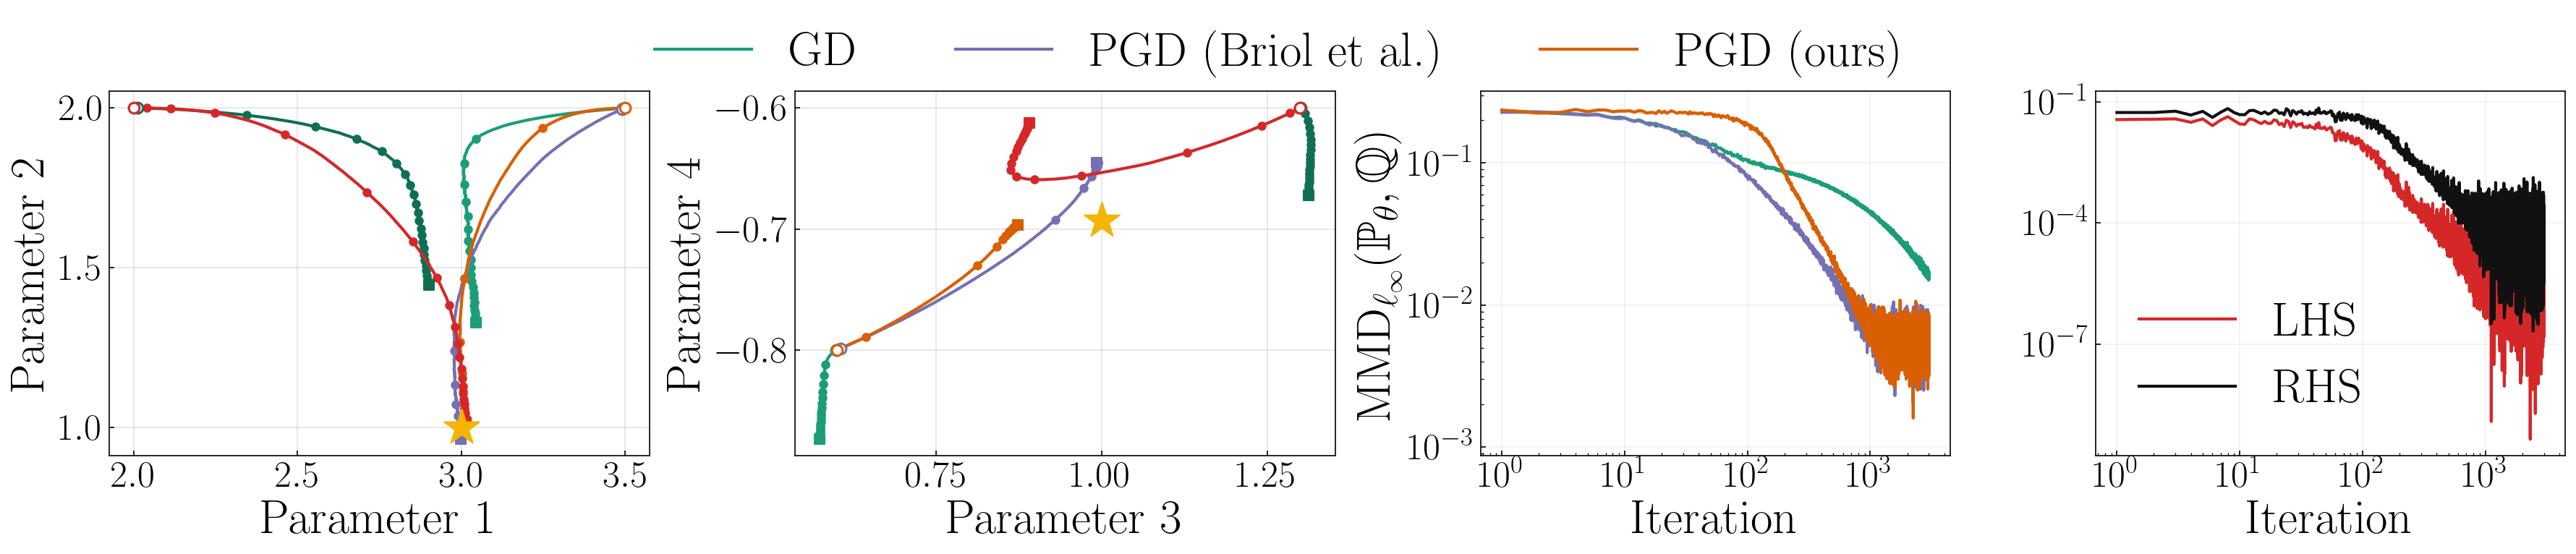

In [56]:
from IPython.display import display

required_inputs = [mmd_npz, *trajectory_npz_paths, lhs_rhs_npz]
missing_inputs = [path for path in required_inputs if not path.exists()]

if not missing_inputs:
    fig = make_gk_summary_figure(
        mmd_npz_path=mmd_npz,
        trajectory_npz_paths=trajectory_npz_paths,
        lhs_rhs_npz_path=lhs_rhs_npz,
        show_method_legend=False,
        show_lhs_rhs_legend=True,
    )
    fig.savefig(OUTPUT_FIGURE, bbox_inches="tight")
    print(f"Saved figure to {OUTPUT_FIGURE}")
    display(fig)
else:
    print(
        f"Figure not rendered because {len(missing_inputs)} source input(s) are missing: "
        + ", ".join(str(path) for path in missing_inputs)
    )


Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_mmd_vs_time.pdf


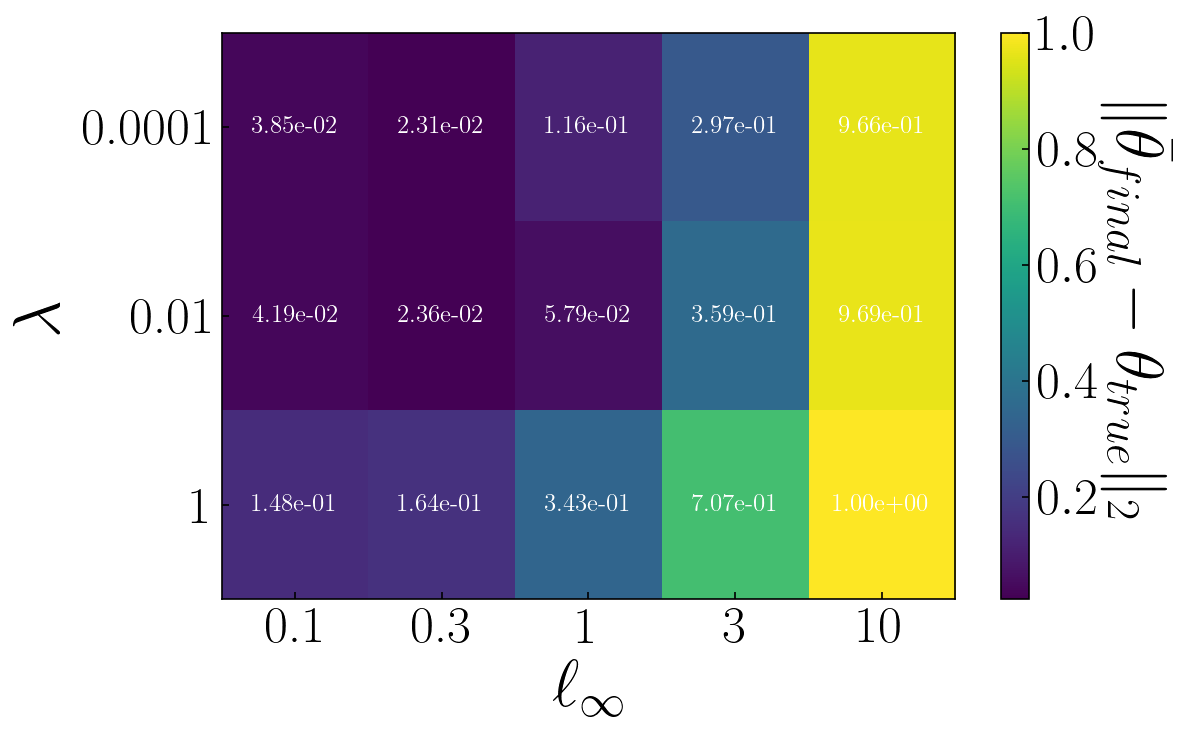

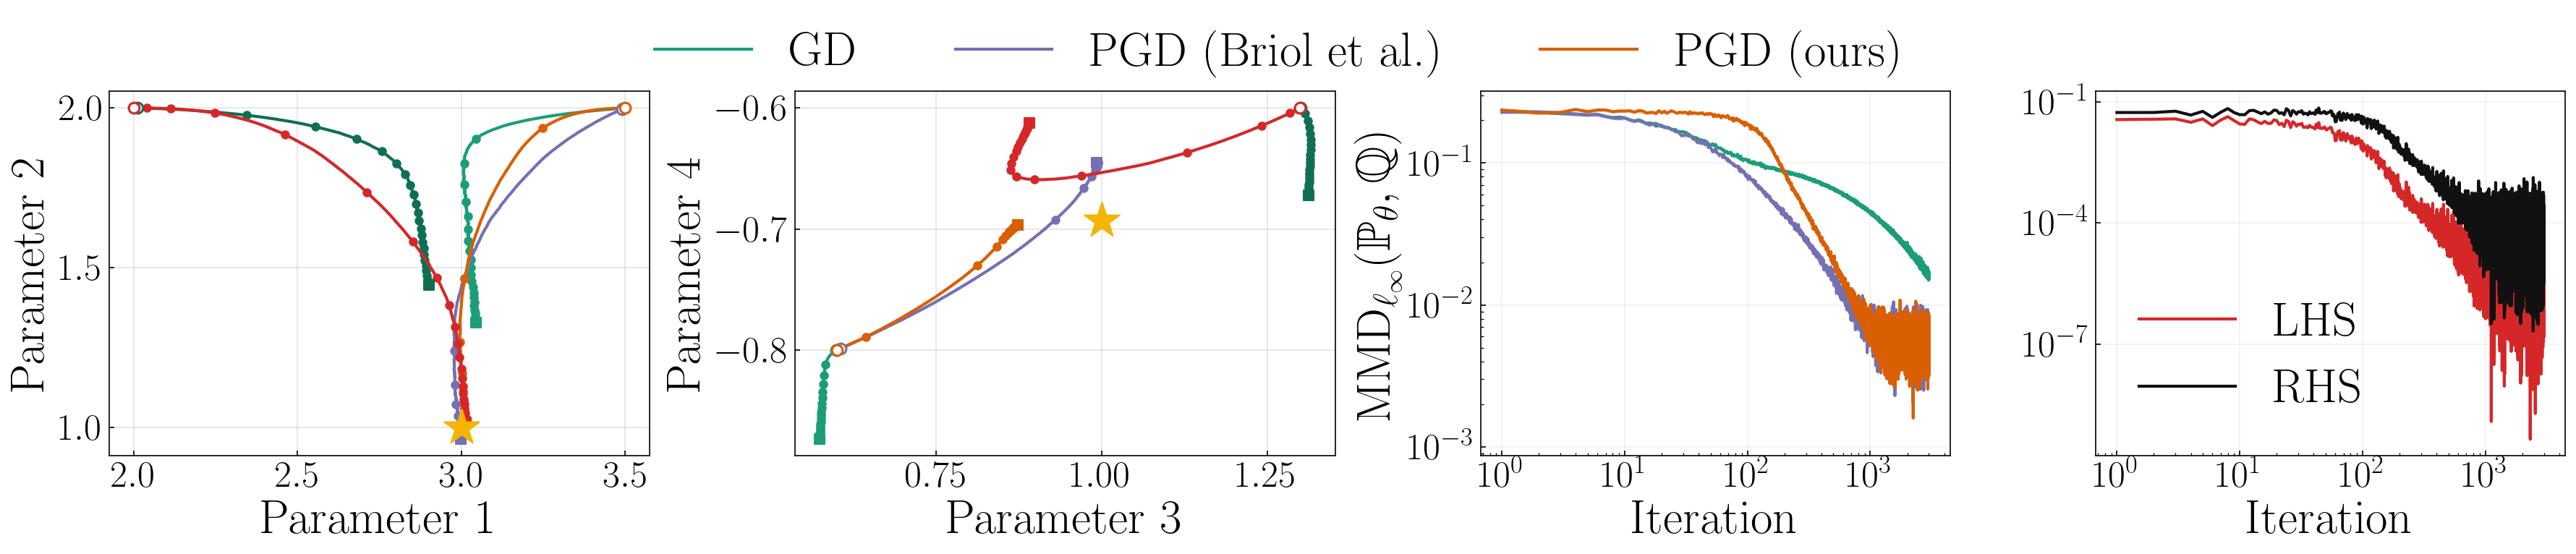

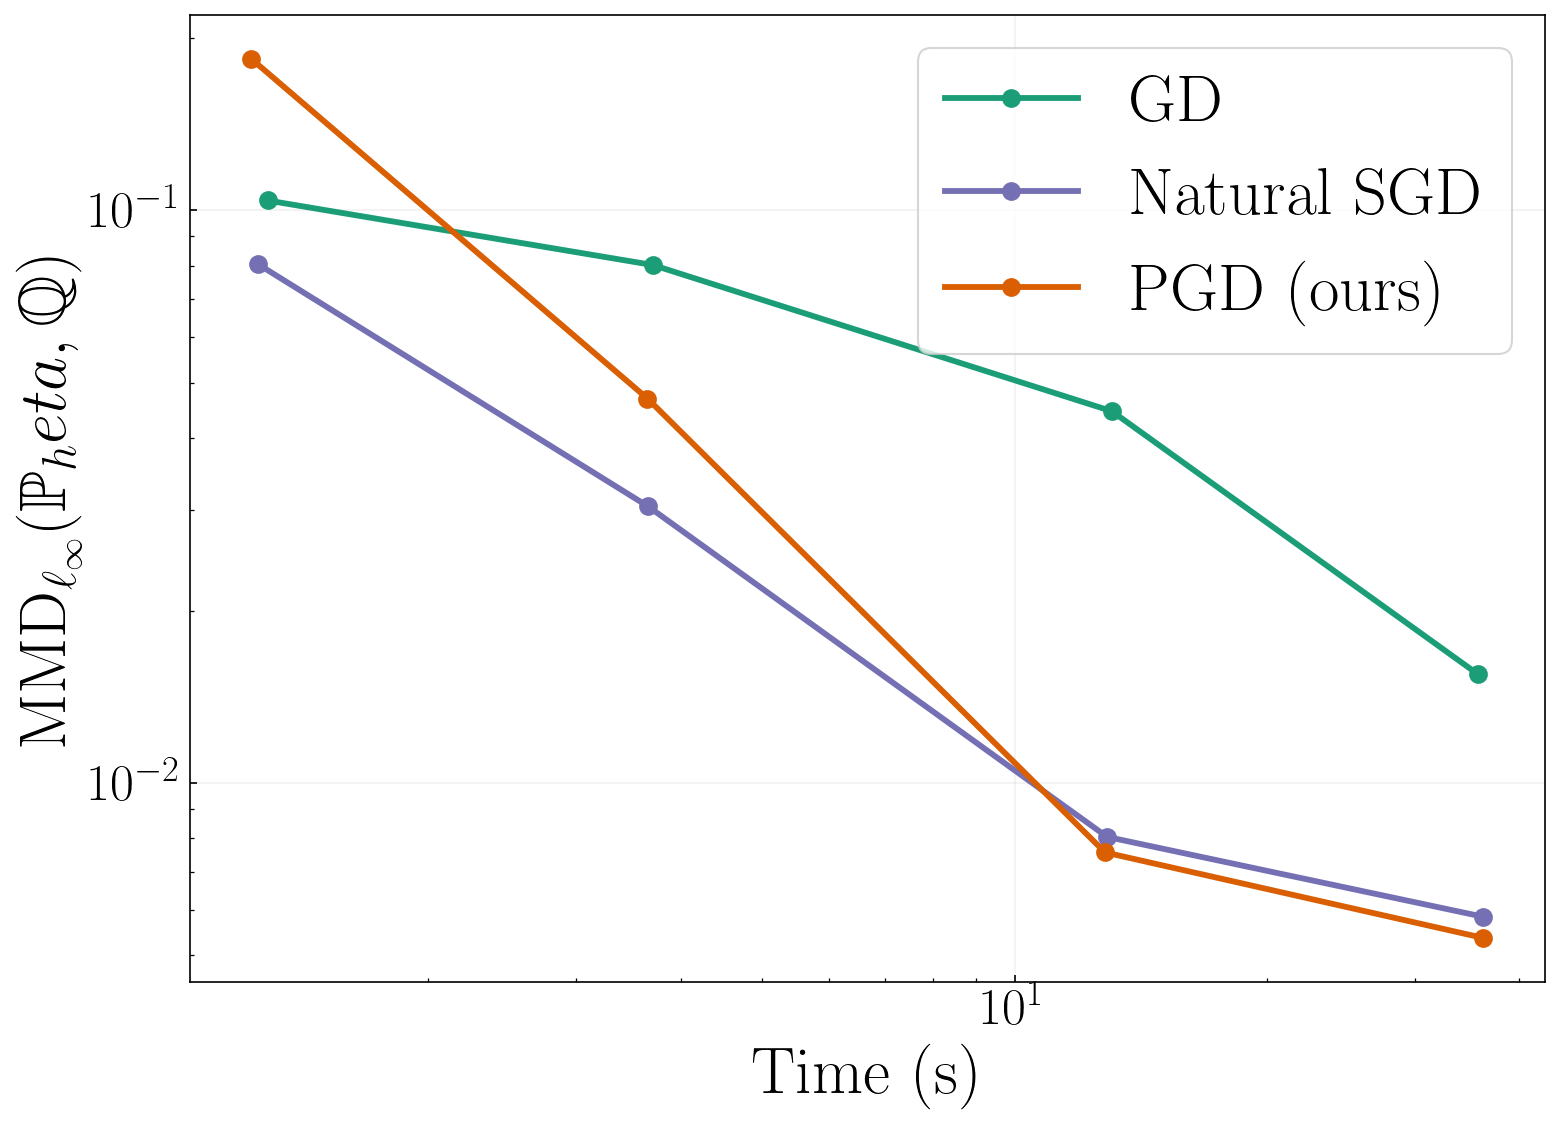

In [57]:
fixed600_time_paths = [
    RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800_100.npz",
    RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800_300.npz",
    RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800_1000.npz",
    RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800_3000.npz",
]
fixed600_time_output = FIGURES_DIR / "gk_mmd_vs_time.pdf"

missing_fixed600 = [path for path in fixed600_time_paths if not path.exists()]
if missing_fixed600:
    print(
        "Fixed-600 time plot not rendered because these input files are missing: "
        + ", ".join(str(path) for path in missing_fixed600)
    )
else:
    method_specs = [
        ("baseline", "GD", COLORS["sgd"]),
        ("natural", "Natural SGD", COLORS["natural"]),
        ("adaptive", "PGD (ours)", COLORS["pgd"]),
    ]

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(10.5, 7.6), dpi=150)

        for prefix, label, color in method_specs:
            times = []
            mmds = []

            for npz_path in fixed600_time_paths:
                data = _load_npz_dict(npz_path)
                times.append(float(np.asarray(data[f"{prefix}_elapsed_mean"], dtype=float)))
                mmds.append(np.sqrt(float(np.asarray(data[f"{prefix}_eval_mean"], dtype=float))))

            times = np.asarray(times, dtype=float)
            mmds = np.asarray(mmds, dtype=float)
            order = np.argsort(times)

            ax.plot(
                times[order],
                mmds[order],
                color=color,
                marker="o",
                linewidth=2.8,
                markersize=8,
                label=label,
            )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel(r"$\mathrm{MMD}_{\ell_\infty}(\mathbb{P}_	heta, \mathbb{Q})$")
        ax.grid(True, which="major", alpha=0.18, linewidth=0.8)
        ax.legend(loc="upper right", frameon=True)
        fig.tight_layout()
        fig.savefig(fixed600_time_output, bbox_inches="tight")
        print(f"Saved figure to {fixed600_time_output}")
        plt.show()


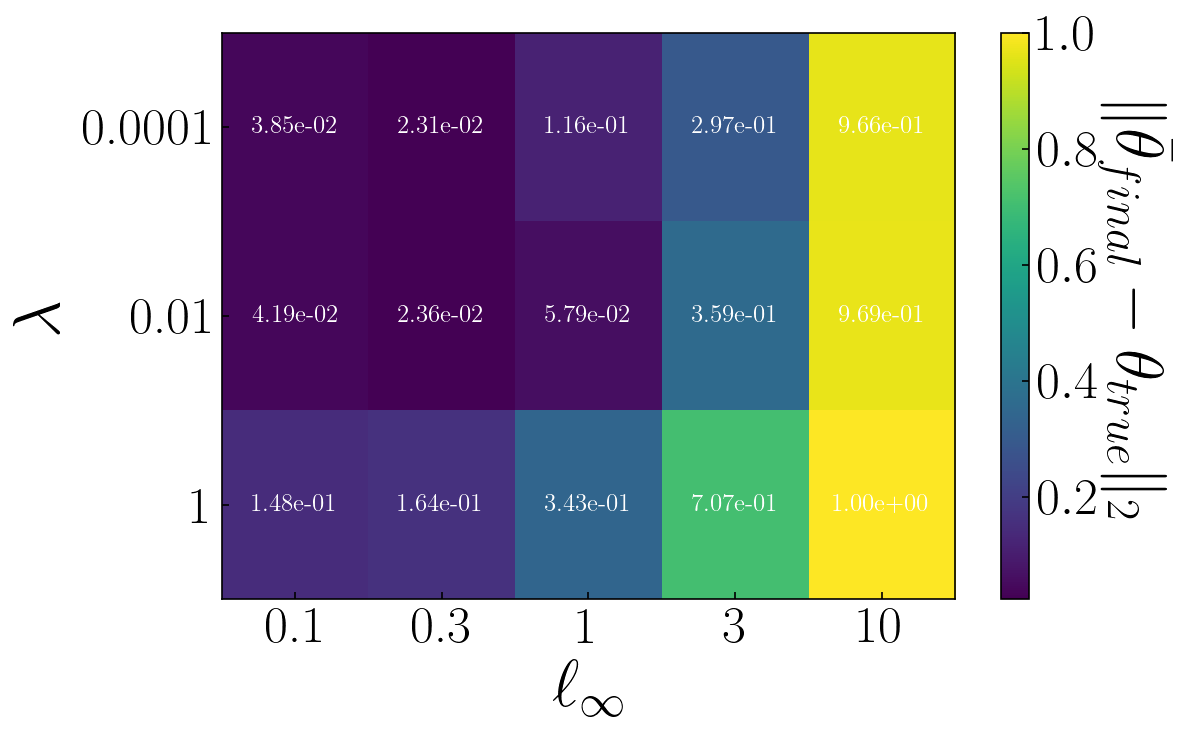

In [58]:
# G-and-K theta-error heatmap from ablations/gk_heatmap
import re


def _parse_heatmap_float(value):
    return float(value.replace("p", "."))


def _draw_theta_error_heatmap(error_grid, ell_values, lambda_values, output_path):
    masked_grid = np.ma.masked_invalid(error_grid)
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad(color="lightgray")

    figure_height = 5.0 if len(lambda_values) > 1 else 2.8
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(8.0, figure_height), dpi=SUMMARY_DPI)
        im = ax.imshow(masked_grid, cmap=cmap, aspect="auto")

        ax.set_xticks(np.arange(len(ell_values)))
        ax.set_yticks(np.arange(len(lambda_values)))
        ax.set_xticklabels([f"{ell:g}" for ell in ell_values])
        ax.set_yticklabels([f"{lam:g}" for lam in lambda_values])
        ax.set_xlabel(r"$\ell_{\infty}$")
        ax.set_ylabel(r"$\lambda$")
        ax.grid(False)

        for i in range(error_grid.shape[0]):
            for j in range(error_grid.shape[1]):
                if np.isfinite(error_grid[i, j]):
                    ax.text(
                        j,
                        i,
                        f"{error_grid[i, j]:.2e}",
                        ha="center",
                        va="center",
                        color="white",
                        fontsize=12,
                    )

        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label(r"$\|\bar{\theta}_{final} - \theta_{true}\|_2$", rotation=270, labelpad=35)
        fig.tight_layout()
        fig.savefig(output_path, bbox_inches="tight")
        return fig


def make_gk_theta_error_heatmap(results_dir, output_path):
    results_dir = Path(results_dir)
    dirname_pattern = re.compile(
        r"g_and_k_lengthscale_regularization_grid_ell_min_"
        r"(?P<ell>[^_]+)_lambda_(?P<lam>[^/]+)$"
    )

    error_by_cell = {}
    ell_values = set()
    lambda_values = set()

    for npz_path in sorted(results_dir.rglob("*.npz")):
        relative_parent = npz_path.parent.relative_to(results_dir).as_posix()
        match = dirname_pattern.match(relative_parent)
        if match is None:
            continue

        ell = _parse_heatmap_float(match.group("ell"))
        lam = _parse_heatmap_float(match.group("lam"))
        data = _load_npz_dict(npz_path)
        theta_true = np.asarray(data["theta_true"], dtype=float)
        theta_final = np.asarray(data["adaptive_theta_mean"], dtype=float)
        theta_error = float(np.linalg.norm(theta_final - theta_true))

        error_by_cell[(lam, ell)] = theta_error
        ell_values.add(ell)
        lambda_values.add(lam)

    if not error_by_cell:
        raise ValueError(f"No G-and-K heatmap files found in {results_dir}")

    sorted_ells = np.asarray(sorted(ell_values), dtype=float)
    sorted_lambdas = np.asarray(sorted(lambda_values), dtype=float)
    error_grid = np.full((len(sorted_lambdas), len(sorted_ells)), np.nan, dtype=float)

    for i, lam in enumerate(sorted_lambdas):
        for j, ell in enumerate(sorted_ells):
            if (float(lam), float(ell)) in error_by_cell:
                error_grid[i, j] = error_by_cell[(float(lam), float(ell))]

    return _draw_theta_error_heatmap(error_grid, sorted_ells, sorted_lambdas, output_path)


gk_theta_error_fig = make_gk_theta_error_heatmap(
    ROOT / "ablations" / "gk_heatmap",
    FIGURES_DIR / "gk_theta_error_ablation.pdf",
)
gk_theta_error_fig